# <center> Практические задания по цифровой обработке сигналов </center>
# <center> Вторая лабораторная работа </center>
# <center> Анализ сигналов </center>

In [ ]:
import hashlib
import warnings

import IPython.display as ipd
import librosa
import matplotlib.pyplot as plt
import numpy as np
import scipy

# Запретим numpy выполнять деление на 0
np.seterr(divide="raise", invalid="raise")
%matplotlib inline
warnings.filterwarnings("ignore")

In [ ]:
# Определим две функции для отрисовки сигнала.
def draw_waveform(wav, sr, figsize=(14, 5)):
    # Отрисовка звукового сигнала во временной области
    plt.figure(figsize=figsize)
    librosa.display.waveshow(wav, sr=sr)


def draw_sig(frames, name=None, figsize=(14, 3)):
    # Отрисовка сигнала в виде "леденцов на палочке"
    plt.figure(figsize=figsize)
    plt.stem(frames)
    if name is not None:
        plt.legend([name])
    plt.xlabel("n")
    plt.ylabel("Energy")
    plt.show()

Создадим несколько простых сигналов. Они нам понадобятся для дальшейшего тестирования

In [ ]:
signals = {}

### Единичный импульс

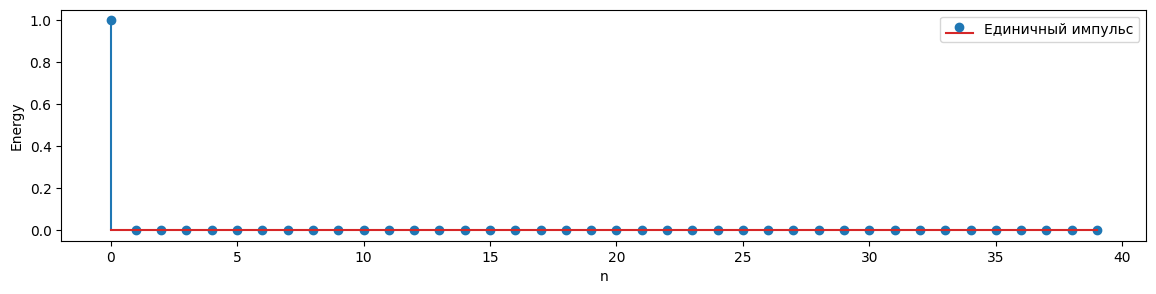

In [ ]:
name = "Единичный импульс"
signals[name] = np.array([1] + [0] * 39, dtype=float)
draw_sig(signals[name], name)

### Единичный скачок

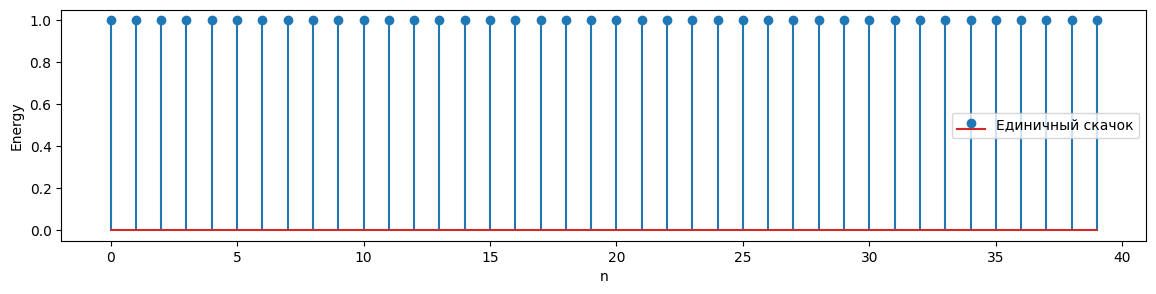

In [ ]:
name = "Единичный скачок"
signals[name] = np.array([1] * 40, dtype=float)
draw_sig(signals[name], name)

### Синус

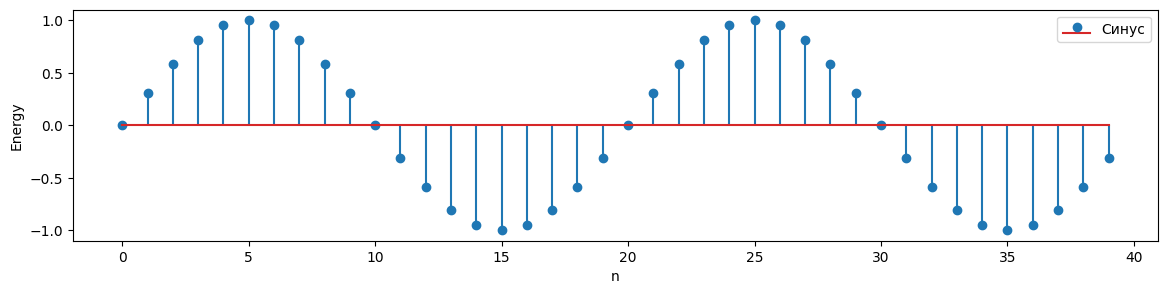

In [ ]:
name = "Синус"
signals[name] = np.sin(np.pi * np.arange(40) / 10)
draw_sig(signals[name], name)

### Шум

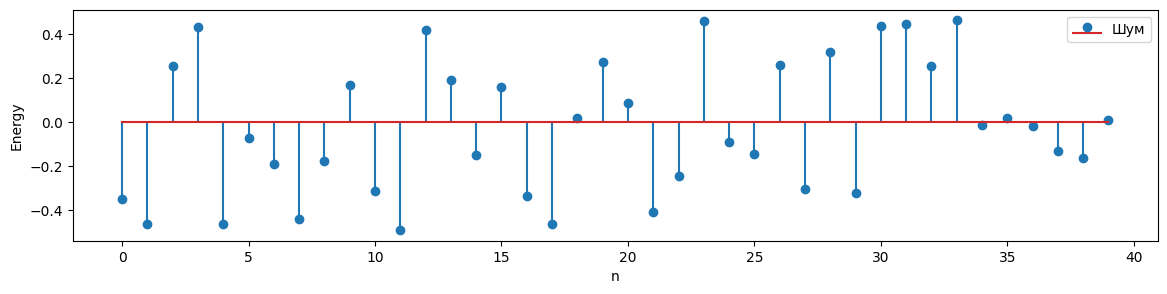

In [ ]:
name = "Шум"
signals[name] = np.random.random(40) - 0.5
draw_sig(signals[name], name)

-------------------------------
# Преобразование Фурье
Прежде, чем перейти к анализу сигналов, надо разобраться, что такое преобразование Фурье. 
> Преобразование Фурье (символ ℱ) — операция, сопоставляющая одной функции вещественной переменной другую функцию вещественной переменной. Эта новая функция описывает коэффициенты («амплитуды») при разложении исходной функции на элементарные составляющие — гармонические колебания с разными частотами (подобно тому, как музыкальный аккорд может быть выражен в виде суммы музыкальных звуков, которые его составляют). [Wiki](https://ru.wikipedia.org/wiki/%D0%9F%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%A4%D1%83%D1%80%D1%8C%D0%B5)



Формула прямого дискретного преобразования Фурье (ДПФ, Discrete Fourier Transform, DFT):
$$ X_k = \sum_{n=0}^{N-1} x_{n} \cdot e^{-i \frac{2\pi}{N} k n} $$


# Задание 1 (2 балла)
Реализовать дискретное преобразование Фурье. Сравнить с реализацией *scipy.fft.fft*

In [ ]:
def DFT(x: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))

    return x @ np.exp((-1j * 2 * np.pi * k * n) / N)

Сравнение с библиотекой scipy

In [ ]:
def test_DTF(x, transform=DFT):
    scipy_result = scipy.fft.fft(x)
    curr_result = transform(x)
    if scipy_result.shape != curr_result.shape:
        print("TEST_FAILED")
        print(f"Your spectrogram shape is {curr_result.shape}. Scipy spectrogram shape is {scipy_result.shape}")
        return -1
    if not np.allclose(curr_result, scipy_result):
        print("TEST FAILED")
        print(f"scipy spectrogram: {scipy_result}")
        print(f"Your DTF spectrogram: {curr_result}")
        print(f"Average diff is {np.mean(np.abs(scipy_result - curr_result))}")
        return -2
    print("TEST PASSED")
    return 0


for name, sig in signals.items():
    print(f"Checking '{name}'")
    assert test_DTF(sig) == 0, "Check you implementation"
print("All ok!")

Checking 'Единичный импульс'
TEST PASSED
Checking 'Единичный скачок'
TEST PASSED
Checking 'Синус'
TEST PASSED
Checking 'Шум'
TEST PASSED
All ok!


Класическое ДПФ имеет существенный недостаток - сложность алгоритма $O(N^2)$. На данный момент существуют чуть более сложные реализации преобразования Фурье, которые избавляются от квадратичной сложности. Например, алгоритм быстрого преобразования Фурье (Fast Fourier Transform, FFT) имеет сложность $O(N log(N))$, что делает его значительно более быстрым на длинных последовательностях. 

# Задание 1.1* (1 балл)
Реализовать быстрое преобразование Фурье. Сравнить с scipy.fft.fft

**Подсказка:** учтите, что для БПФ нам нужно, чтобы количество отсчетов сигнала было степенью двойки

In [ ]:
def FFT(x: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    # это DIT вариант
    x = np.asarray(x, dtype=complex)
    N = len(x)
    if N == 1:
        return x

    X0 = FFT(x[0::2])  # odd
    X1 = FFT(x[1::2])  # even
    k = np.arange(N // 2)
    W = np.exp(-2j * np.pi * k / N)
    fst = X0 + W * X1
    snd = X0 - W * X1

    return np.concat([fst, snd])

In [ ]:
orig_signals = dict(signals.items())

for name, signal in signals.items():
    N = len(signal)
    len_ = np.log2(N)
    if len_ != int(len_):
        to_pad = 2 ** (int(len_) + 1) - N
        signals[name] = np.pad(signal, (0, to_pad), mode="constant", constant_values=[0])

In [ ]:
for name, sig in signals.items():
    print(f"Checking '{name}'")
    assert test_DTF(sig, transform=FFT) == 0, "Check you implementation"
print("All ok!")

Checking 'Единичный импульс'
TEST PASSED
Checking 'Единичный скачок'
TEST PASSED
Checking 'Синус'
TEST PASSED
Checking 'Шум'
TEST PASSED
All ok!


Если вы изменяли длительность исходных сигналов, не забудьте вернуть их изначальную длительность

In [ ]:
# YOUR CODE HERE
signals = orig_signals

# Амплитудный и фазовый спектры
Поскольку преобразование Фурье определено в комплекстной области, анализировать результат напрямую проблематично. Для анализа сигналов принято разбивать результат преобразования Фурье на два спектра: амплитудный и фазовый. Амплитудный показывает, как меняется модуль сигнала, а фазовый - как меняется угол, образуемый на комплексной плоскости. 
# Задание 2 (1 балл)

Реализовать функции построения амплитудного и фазового спектра

In [ ]:
# функция построения амплитудного спектра
def get_amplitude_from_spec(spec: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    return np.abs(spec)


# функция построения фазового спектра
def get_phi_from_spec(spec: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    return np.angle(spec)

In [ ]:
def check_mean_var(sig, mean=None, var=None):
    if mean is not None and np.mean(sig) != mean:
        print(f"Bad mean. Expected {mean}, got {np.mean(sig)}")
        return False
    if var is not None and np.var(sig) != var:
        print(f"Bad var. Expected {var}, got {np.var(sig)}")
        return False
    return True


_spec = scipy.fft.fft(np.array([1] + [0] * 10))
assert check_mean_var(get_amplitude_from_spec(_spec), 1.0, 0.0), "Wrong Amplitude"
assert check_mean_var(get_phi_from_spec(_spec), 0.0, 0.0), "Wrong Phase"


_spec = scipy.fft.fft(np.array([1] * 10))
assert check_mean_var(get_amplitude_from_spec(_spec), 1.0, 9.0), "Wrong  Amplitude"
assert get_amplitude_from_spec(_spec)[0] == 10, "Wrong Amplitude"
assert get_phi_from_spec(_spec)[0] == 0, "Wrong phase"

_spec = scipy.fft.fft(scipy.fft.ifft(np.array([0] + [10 + 5j] + [0] * 6 + [10 - 5j])))
assert get_amplitude_from_spec(_spec).round(1)[1] == 11.2, "Wrong Amplitude. Make sure it is a complex number module."
assert get_phi_from_spec(_spec).round(1)[1] == 0.5, "Wrong Amplitude. Make sure it is an angle."


print("All OK!")

All OK!


Определим еще одну функцию для отрисовки. Теперь будем рисовать сигнал в частотной области

In [ ]:
def draw_spec(spec, name=None, draw_A=True, draw_p=True, figsize=(14, 3)):
    # Рисуем точки как "леденцы на палочках"
    # или
    # При большом N "леденцы" выглядят плохо,
    # Поэтому будем рисовать огибающую функцию
    draw_func = plt.stem if len(spec) < 100 else plt.plot

    if draw_A:
        plt.figure(figsize=figsize)
        plt.title("Amplitude spectrum")
        spec_A = get_amplitude_from_spec(spec)
        draw_func(spec_A)
        plt.ylabel("Magnitude")
        plt.xlabel("n")
        if name is not None:
            plt.legend([name])
        plt.show()

    if draw_p:
        plt.figure(figsize=figsize)
        plt.title("Phase spectrum")
        phi = get_phi_from_spec(spec)
        draw_func(phi)
        plt.ylabel("Radian")
        plt.xlabel("n")
        if name is not None:
            plt.legend([name])
        plt.show()
    return

# Задание 2.1 (0.5 балла)
Постройте спектры для всех сигналов из коллекции signals и ответьте на вопросы:
<!-- 1. Почему амплитуда всех гармоник единичного импульса равна единице? 
1. Какие выводы можно сделать смотря на амплитудный спектр? А на фазовый? 
1. Как перевести номер отсчета в частоту?  
1. Что в фазовом спектре является полезной информацией, а что - шумом? Почему? -->

### Визуализация:

Checking 'Единичный импульс'


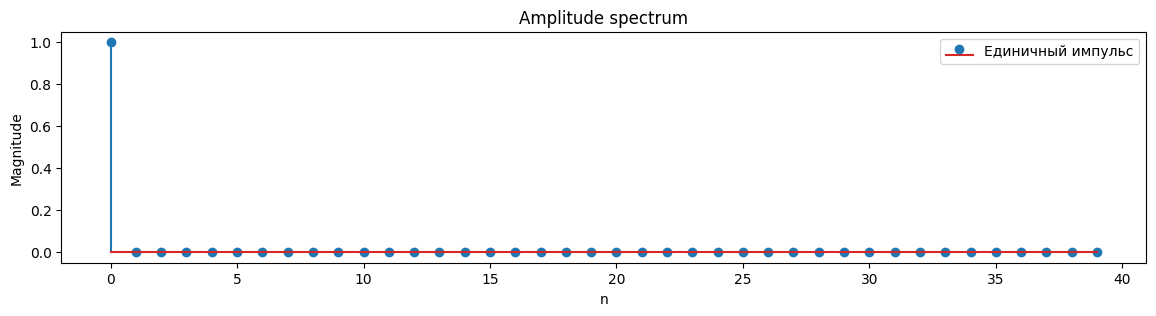

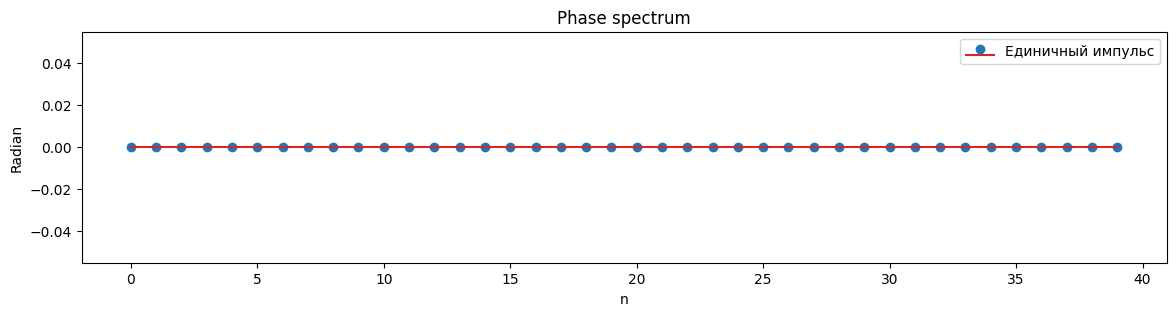

Checking 'Единичный скачок'


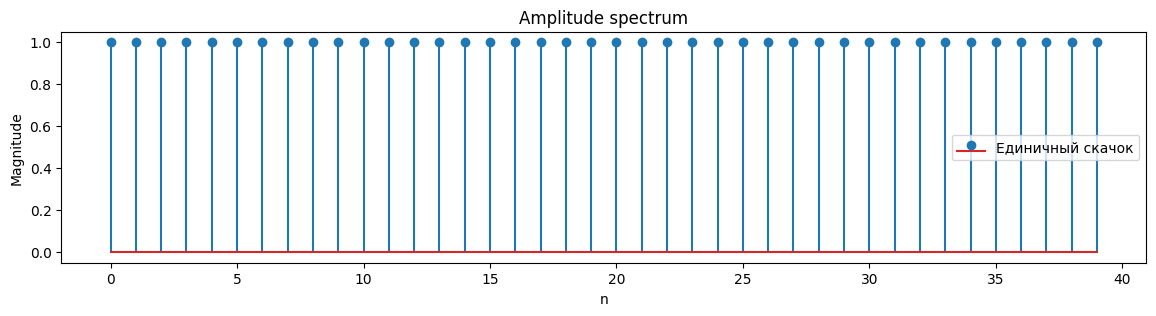

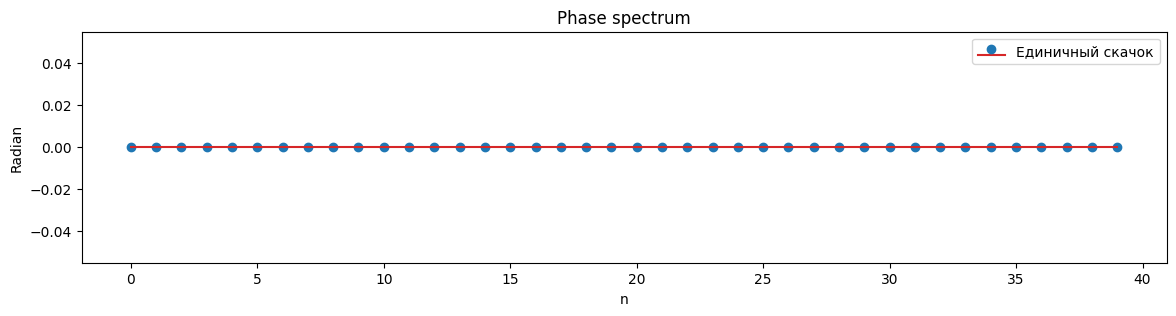

Checking 'Синус'


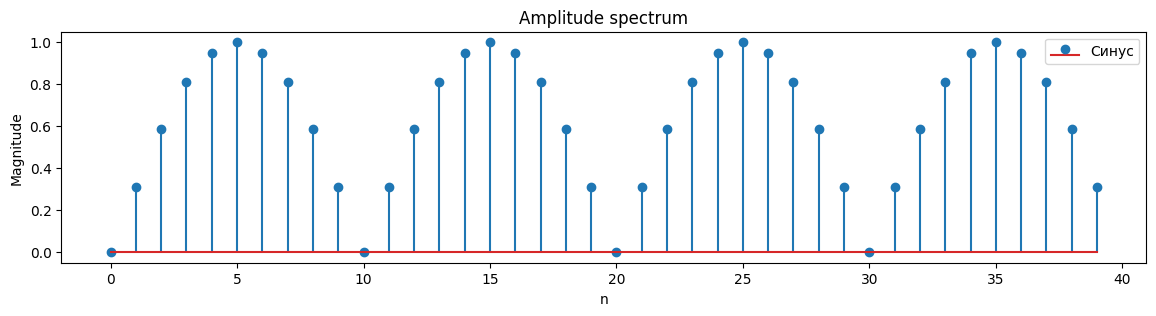

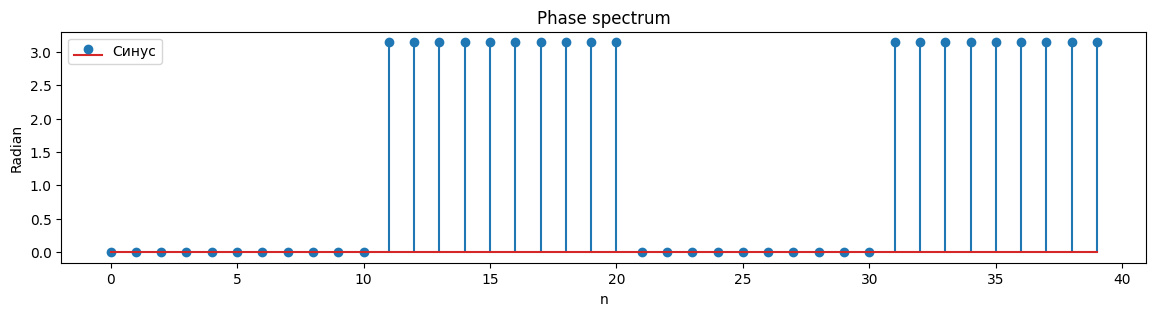

Checking 'Шум'


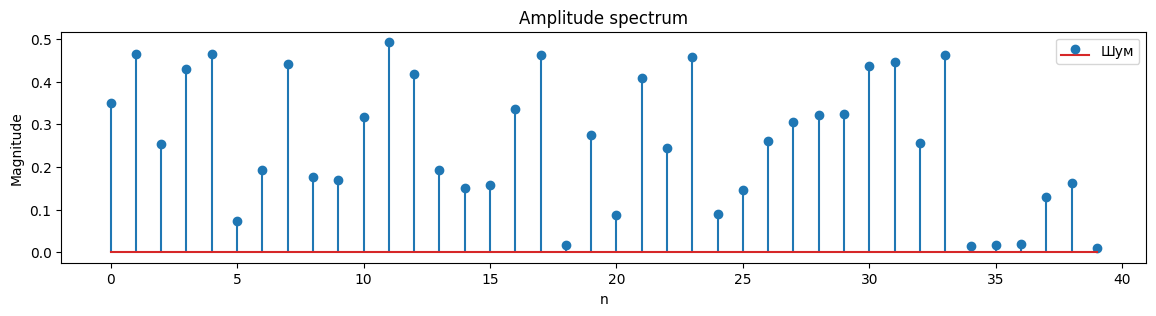

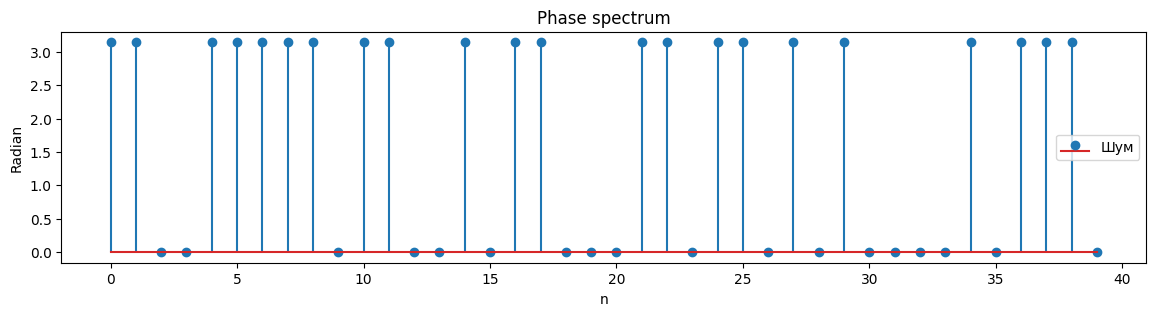

All ok!


In [ ]:
# YOUR CODE HERE
for name, sig in signals.items():
    print(f"Checking '{name}'")
    draw_spec(spec=sig, name=name)
print("All ok!")

### 1.Почему амплитуда всех гармоник единичного импульса равна константе?

**Ответ:** ДПФ от единичного импульса равен константе, импульс содержит энергию на всех частотах одновременно

### 2. Какие выводы можно сделать смотря на амплитудный спектр? А на фазовый?

**Ответ:**

**Амплитудный** показывает, какие частоты с какой силой есть в нашем сигнале. Чем больше столбик, тем больше именной этой частоты в нашем сигнале

**Фазовый** показывает задержку синусоид относительно нулевой точки отчёта

### 3. Как перевести номер отсчета в частоту?

**Ответ:** чтобы перевести номер отсчёта гармоники в частоту, нужно умножить её на частоту дискретизации и поделить на общее число отсчётов:

$$f_k = \frac{k \cdot f_s}{N}$$

### 4. Что в фазовом спектре является полезной информацией, а что - шумом? Почему?

# Оконное преобразование Фурье
Преобразование Фурье делает переход из временной области в частотную, позволяя анализировать составляющие сигнал гармоники. Однако это не всегда удобно. В реальных сигналах зачастую составляющие их гармоники изменяются со временем. Например, каждая буква в слове имеет свой набор основных гармоник, и простое преобразование Фурье не сильно поможет нам определить, что было сказано. Для того, чтобы анализировать такие сигналы, обычно используется [Оконное преобразование Фурье](https://ru.wikipedia.org/wiki/Оконное_преобразование_Фурье). Такое преобразование позволяет анализировать гармоники сигнала в коротких промежутках времени и сохранить временную ось при построении спектрограммы.
# Задание 3 (2 балла)
Реализовать оконное преобразование Фурье (Short-time Fourier transform), пользуясь только библиотеками *numpy* и *scipy*. Сравнить с *librosa.stft*


In [ ]:
def STFT(x: np.ndarray, n_fft: int = 2048, hop_length: int = 512, window: str = "hann") -> np.ndarray:
    # x - signal
    # n_fft - fft window size
    # hop_length - step size between ffts
    # window - window type. See scipy.signal.get_window
    # return spectrogram

    # YOUR CODE HERE
    window_func = scipy.signal.get_window(window, n_fft, fftbins=True)

    # центрируем как в librosa
    pad = n_fft // 2
    x_padded = np.pad(x, (pad, pad), mode="constant", constant_values=[0])

    num_frames = 1 + (len(x_padded) - n_fft) // hop_length
    stft_matrix = np.zeros((n_fft // 2 + 1, num_frames), dtype=np.complex64)

    for i in range(num_frames):
        l = i * hop_length
        r = l + n_fft
        frame = x_padded[l:r]

        windowed = frame * window_func
        fft_frame = scipy.fft.rfftn(windowed)
        stft_matrix[:, i] = fft_frame

    return stft_matrix

In [ ]:
def test_stft(x: np.ndarray, n_fft: int = 2048, hop_length: int = 512, window: str = "hann"):
    librosa_result = librosa.stft(x, n_fft=n_fft, hop_length=hop_length, window="hann", center=True)
    result = STFT(x, n_fft=n_fft, hop_length=hop_length, window="hann")
    if librosa_result.shape != result.shape:
        print(f"Your shape {result.shape} != librosa stft shape {librosa_result.shape} ")
        return -1
    if not np.allclose(librosa_result, result):
        print(f"Wrong results. Diff {np.abs(librosa_result - result)}")
        return -2
    return 0


for name, sig in signals.items():
    print(f"Checking '{name}'")
    for n_fft in (8, 4):
        for hop_length in (n_fft // 4, n_fft // 2):
            assert test_stft(sig, n_fft=n_fft, hop_length=hop_length) == 0, (
                f"Test failed. Params n_fft {n_fft}. Hop_length {hop_length}"
            )
    print("ok")
print("All ok!")

Checking 'Единичный импульс'
ok
Checking 'Единичный скачок'
ok
Checking 'Синус'
ok
Checking 'Шум'
ok
All ok!


Определим функцию для отрисовки

In [ ]:
# Определим функцию для отрисовки
def draw_stft(X, sr, figsize=(14, 5)):
    plt.figure(figsize=figsize)
    # X - комплекстная спектрограмма
    # Для получения энергии достаточно взять модуль
    Xdb = librosa.amplitude_to_db(abs(X))
    librosa.display.specshow(Xdb, sr=sr, x_axis="time", y_axis="hz")
    plt.show()

# Анализ сигналов
Теперь можно приступить к анализу звуковых сигналов.
Во время анализа сигналов нам понадобятся все определенные выше инструменты. 


----------------------------------
## Анализ паровозного гудка
Начнем с простого сигнала, состоящего из нескольких основных гармоник и шума.

Загрузим аудио файл с паровозным гудком

Len is 82175 ( ). Sample rate is 22050


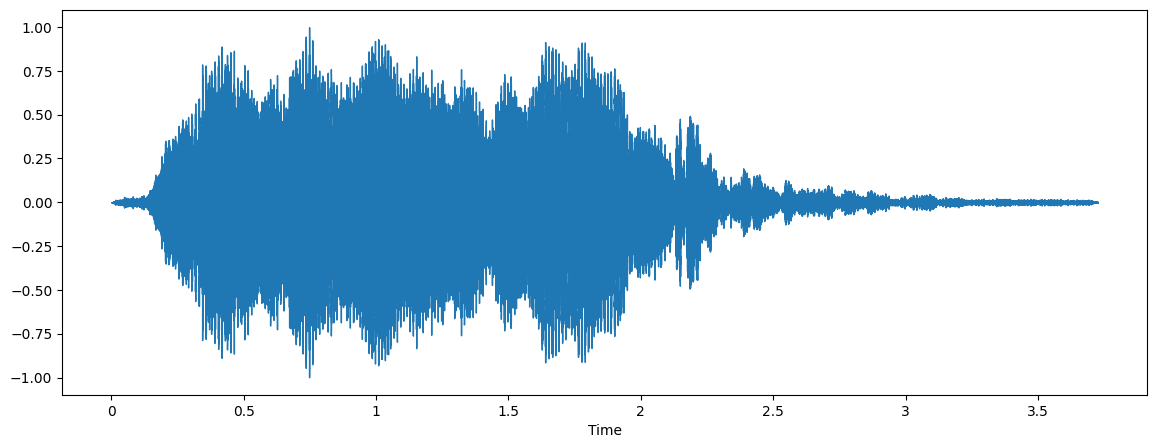

In [ ]:
# Загрузим аудио файл с паровозным гудком
train_whistle, tw_sr = librosa.core.load("resources/train_whistle.wav")
print(f"Len is {len(train_whistle)} ( ). Sample rate is {tw_sr}")
player = ipd.Audio(train_whistle, rate=tw_sr)
ipd.display(player)
draw_waveform(train_whistle, sr=tw_sr)

Построим гудок паровоза в частотной области

Гудок паровоза в частотной области


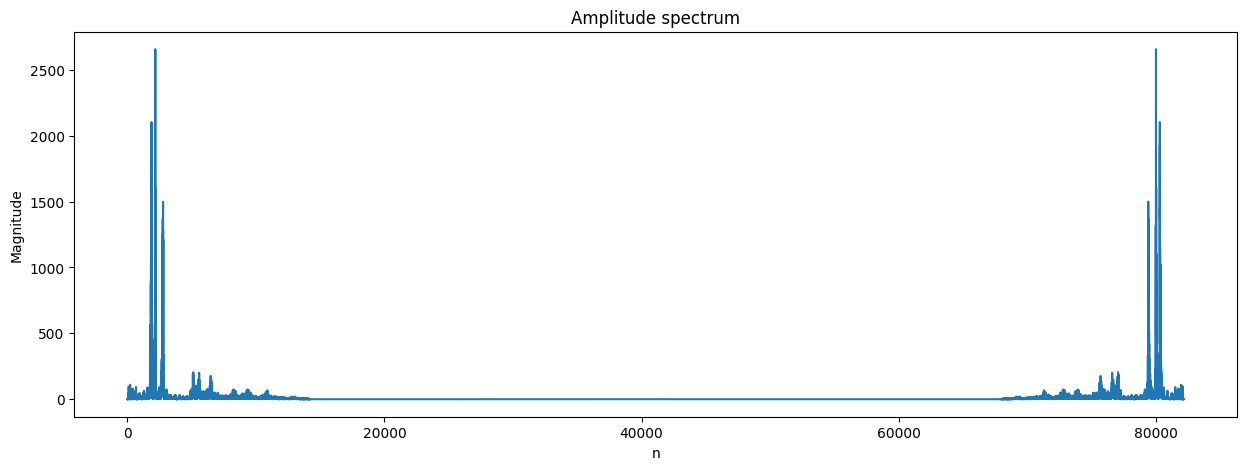

In [ ]:
train_whistle_spec = scipy.fft.fft(train_whistle)
print("Гудок паровоза в частотной области")
draw_spec(train_whistle_spec, draw_p=False, figsize=(15, 5))

# Задание 4 (2 балла)
Определите 3 основные гармоники паровозного гудка.

Ответ округлите до двух знаков после запятой.


Приближаем наши пики и видим, что у нас 3 таких пика

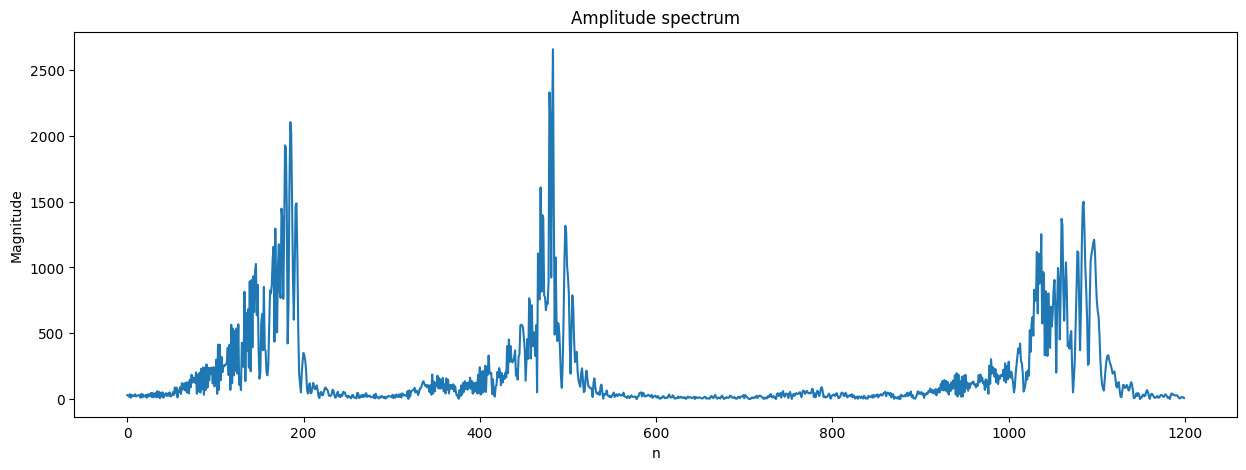

In [ ]:
draw_spec(train_whistle_spec[1700:2900], draw_p=False, figsize=(15, 5))

Амплитудный спектр

In [ ]:
# YOUR CODE HERE
fft = np.fft.rfft(train_whistle)
N = len(train_whistle)
frequencies = np.fft.rfftfreq(N, d=1 / tw_sr)
magnitude = get_amplitude_from_spec(fft)

# берём треть от макс длины по нашему графику
peaks, _ = scipy.signal.find_peaks(magnitude, height=0.3 * np.max(magnitude), distance=100)
#  объединяем амплитуды и индексы пиков, сортируем по убыванию амплитуды, затем берем 3 самых больших пика
top_peaks = sorted(zip(magnitude[peaks], peaks), reverse=True)[:3]
print("Амплитуды:", ", ".join([str(int(amp)) for amp, _ in top_peaks]))

Амплитуды: 2656, 2103, 1499


In [ ]:
idx = 0
harmonic_frequencies = [0 for _ in range(len(top_peaks))]
t = np.linspace(0, len(train_whistle) / tw_sr, len(train_whistle))

### 1 гармоника

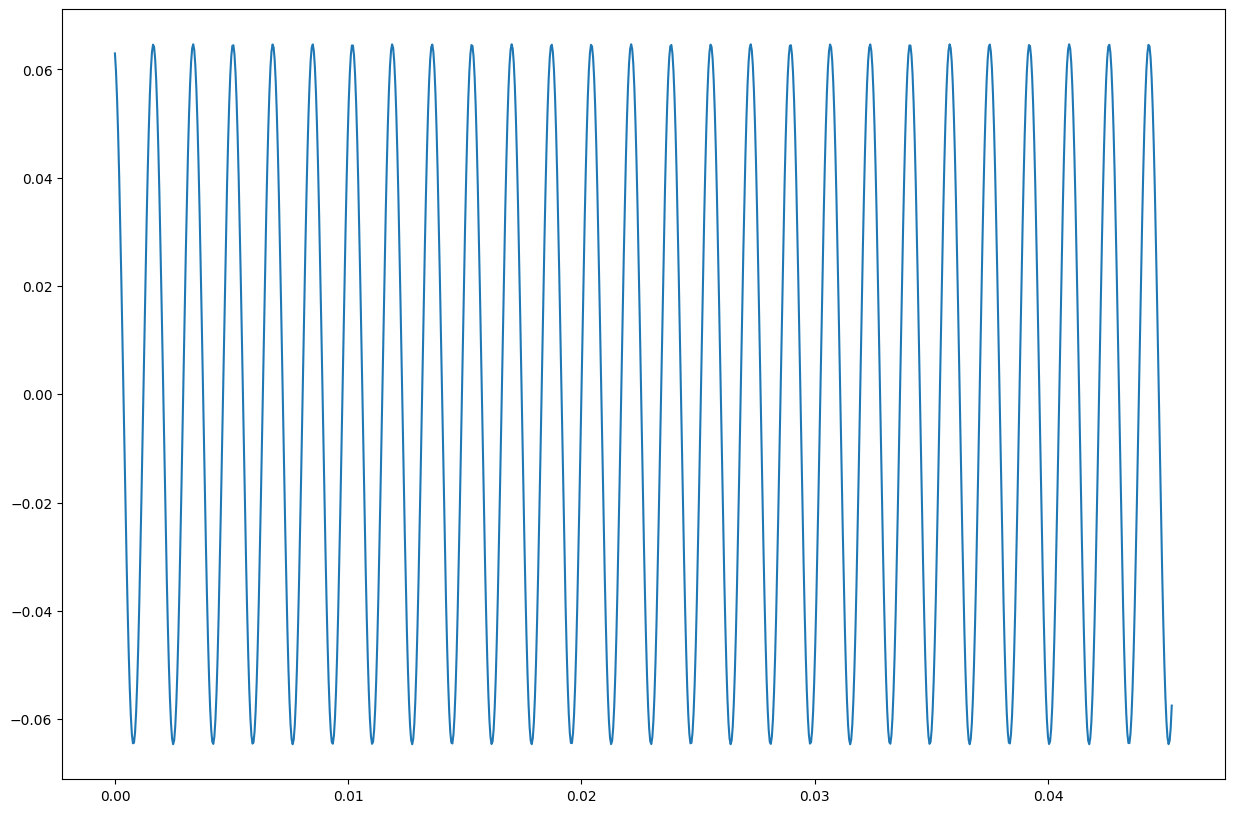

In [ ]:
# # YOUR CODE HERE
harmonic_frequencies[idx] = frequencies[top_peaks[idx][1]]
A = 2 * top_peaks[idx][0] / len(train_whistle)
func = A * np.cos(2 * np.pi * harmonic_frequencies[idx] * t + np.angle(fft[top_peaks[idx][1]]))

plt.figure(figsize=(15, 10))
plt.plot(t[:1000], func[:1000])
plt.show()

### 2 гармоника

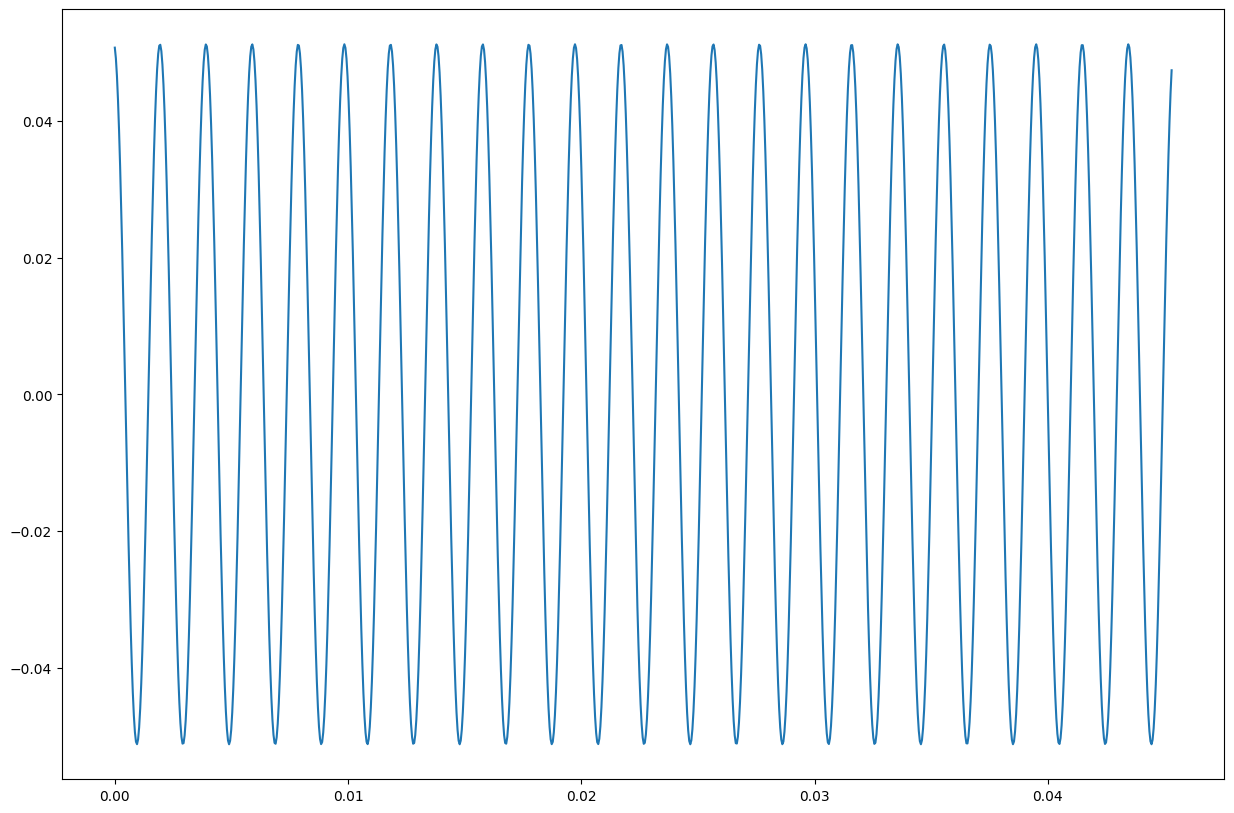

In [ ]:
# YOUR CODE HERE
idx += 1
harmonic_frequencies[idx] = frequencies[top_peaks[idx][1]]
A = 2 * top_peaks[idx][0] / len(train_whistle)
func = A * np.cos(2 * np.pi * harmonic_frequencies[idx] * t + np.angle(fft[top_peaks[idx][1]]))

plt.figure(figsize=(15, 10))
plt.plot(t[:1000], func[:1000])
plt.show()

### 3 гармоника

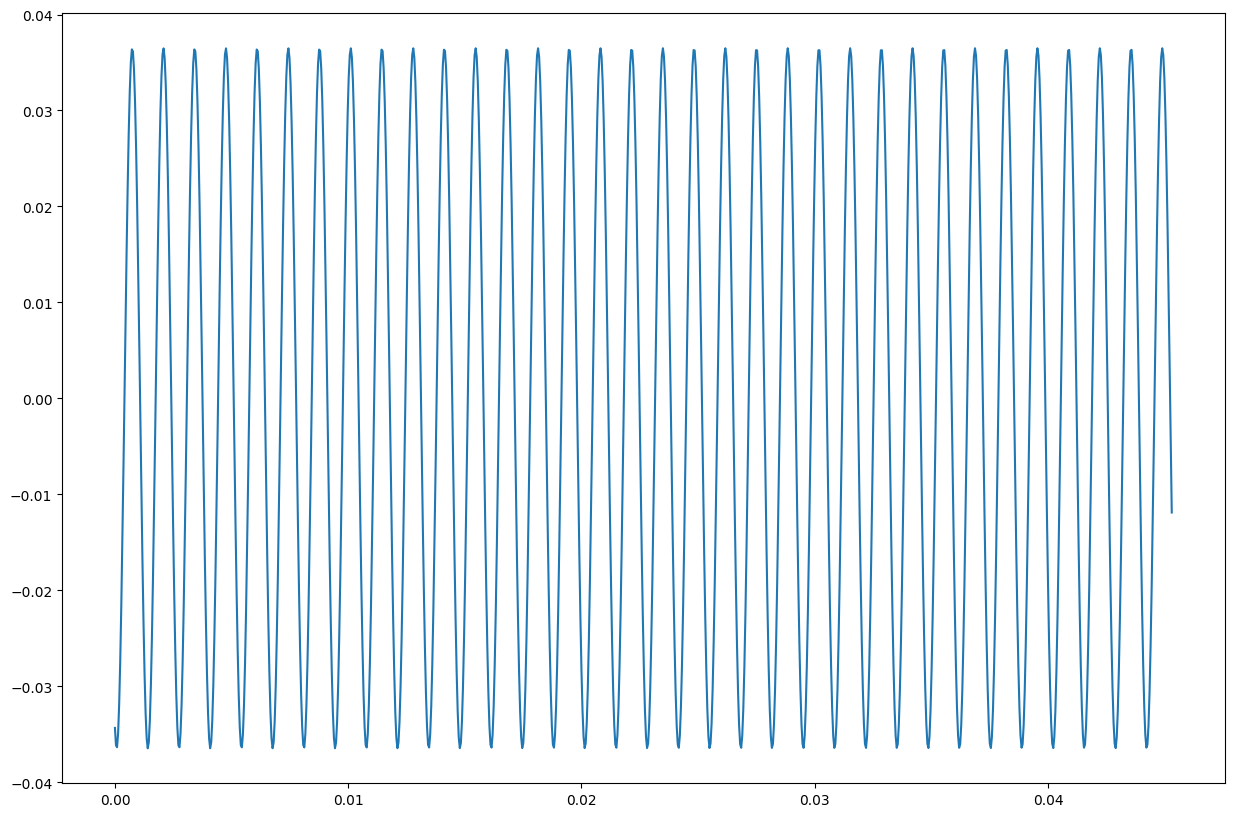

In [ ]:
# YOUR CODE HERE
idx += 1
harmonic_frequencies[idx] = frequencies[top_peaks[idx][1]]
A = 2 * top_peaks[idx][0] / len(train_whistle)
func = A * np.cos(2 * np.pi * harmonic_frequencies[idx] * t + np.angle(fft[top_peaks[idx][1]]))

plt.figure(figsize=(15, 10))
plt.plot(t[:1000], func[:1000])
plt.show()

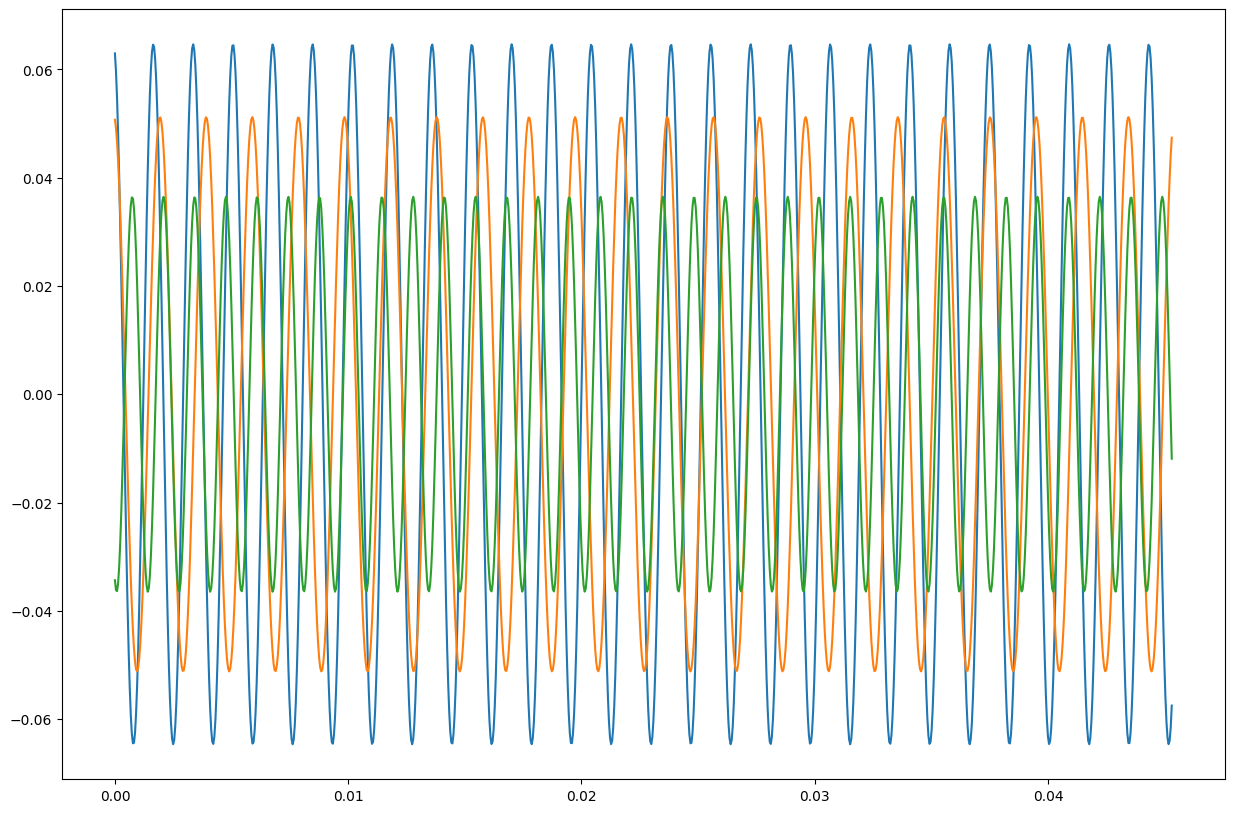

In [ ]:
# YOUR CODE HERE
plt.figure(figsize=(15, 10))
for i in range(len(harmonic_frequencies)):
    A = 2 * top_peaks[i][0] / len(train_whistle)
    func = A * np.cos(2 * np.pi * harmonic_frequencies[i] * t + np.angle(fft[top_peaks[i][1]]))

    plt.plot(t[:1000], func[:1000])
plt.show()

### Тест

In [ ]:
# task_answer = [ freq1, freq2, freq3 ]
task_answer = harmonic_frequencies

In [ ]:
assert isinstance(task_answer, (list, np.ndarray)), (
    f"Wrong answer type. Expected list or numpy array. Got {type(task_answer)}"
)
assert len(task_answer) == 3, f"Wrong len {len(task_answer)}."
assert (round(sum(task_answer)) == 1677 and round(np.var(task_answer)) == 1407) or (
    abs(sum(task_answer) - 1836) <= 3 and abs(np.var(task_answer) - 10153) <= 181
), "Wrong freqs"
print("Correct!")

Correct!


Теперь попробуйте сгенерировать сигнал, состоящий только из этих гармоник. Воспроизведите сигнал.

In [ ]:
# YOUR CODE HERE
window = "hann"
nperseg = 512
noverlap = 256

f, t_stft, Zxx = scipy.signal.stft(train_whistle, fs=tw_sr, window="hann", nperseg=nperseg, noverlap=noverlap)

# забираем индексы гармоник
harmonic_indices = []
for target_freq in harmonic_frequencies:
    idx = np.argmin(np.abs(f - target_freq))
    harmonic_indices.append(idx)

# отбираем нужные stft
Zxx_filtered = np.zeros_like(Zxx, dtype=complex)
for idx in harmonic_indices:
    Zxx_filtered[idx, :] = Zxx[idx, :]

t_recon, reconstructed = scipy.signal.istft(Zxx_filtered, fs=tw_sr, window="hann", nperseg=nperseg, noverlap=noverlap)

# отризаем лишнее
if len(reconstructed) > len(train_whistle):
    reconstructed = reconstructed[: len(train_whistle)]
else:
    reconstructed = np.pad(
        reconstructed,
        (0, len(train_whistle) - len(reconstructed)),
        mode="constant",
        constant_values=[0],
    )

Оригинал:


Inverse STFT:


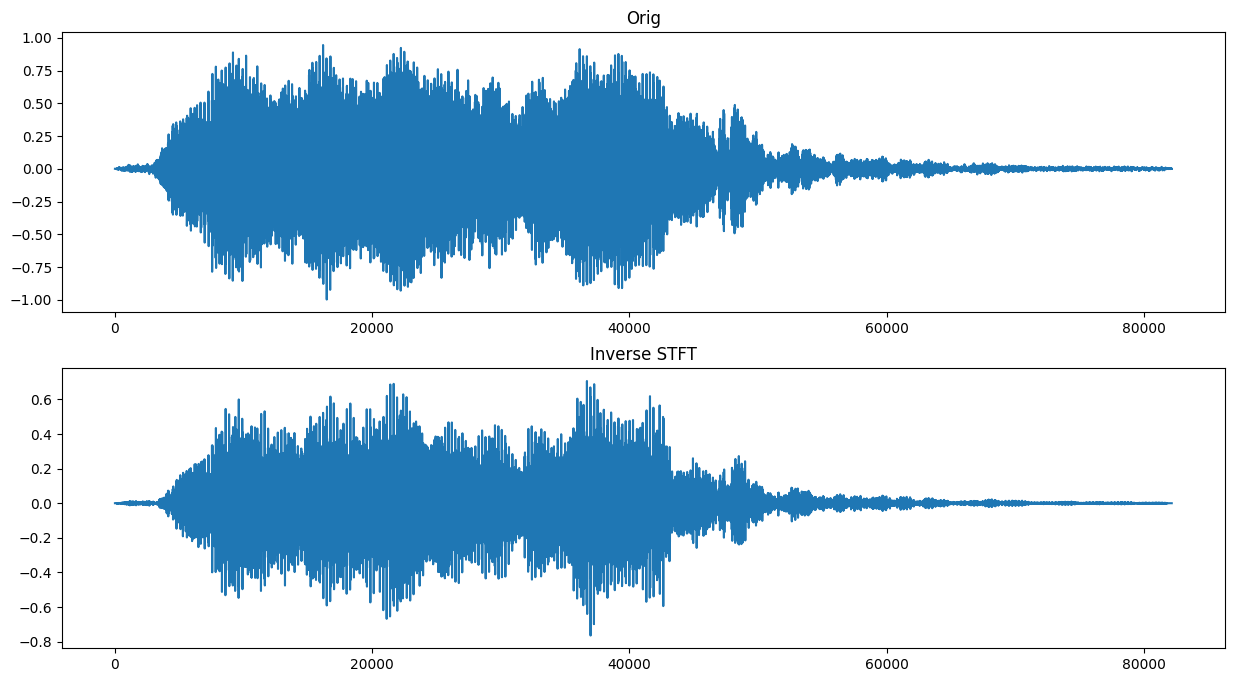

In [ ]:
print("Оригинал:")
ipd.display(ipd.Audio(train_whistle, rate=tw_sr))
print("Inverse STFT:")
ipd.display(ipd.Audio(reconstructed, rate=tw_sr))

_, ax = plt.subplots(2, figsize=(15, 8))
ax[0].plot(train_whistle)
ax[0].set_title("Orig")

ax[1].plot(reconstructed)
ax[1].set_title("Inverse STFT")
plt.show()

# Анализ двухтонального многочастотного сигнала
Теперь расмотрим более сложный сигнал - [DTMF](https://en.wikipedia.org/wiki/Dual-tone_multi-frequency_signaling). Такие сигналы используются для автоматизации набора телефонного номера. 

# Задание 5 (2 балла)
В данном аудио закодирован трехзначный номер. Используя таблицу с [wiki](https://ru.wikipedia.org/wiki/DTMF) определите, что за номер закодирован.


Визуализация

Len is 243102. Sample rate is 22050


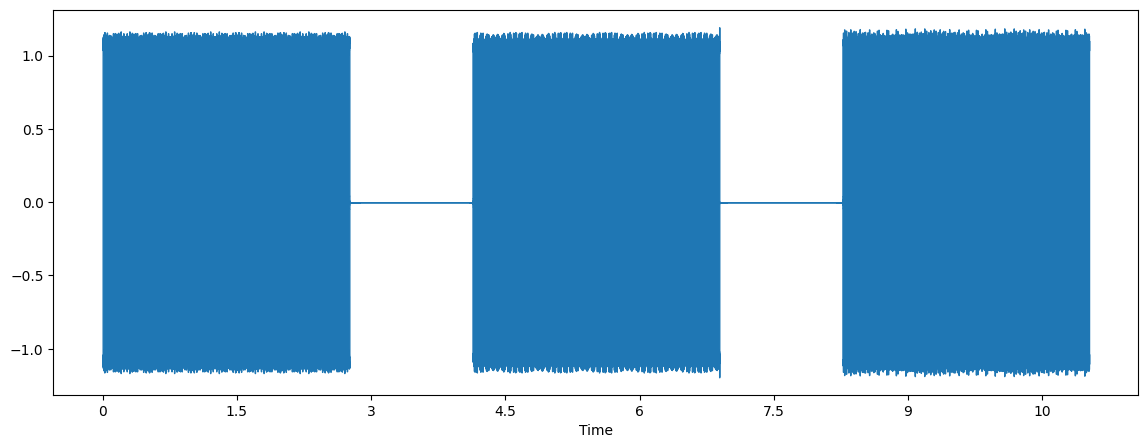

In [ ]:
# dtmf.wav
dtmf, dtmf_sr = librosa.load("resources/dtmf.wav")
print(f"Len is {len(dtmf)}. Sample rate is {dtmf_sr}")
player = ipd.Audio(dtmf, rate=dtmf_sr)
ipd.display(player)
draw_waveform(dtmf, sr=dtmf_sr)

In [ ]:
dtmf_freqs = {
    (697, 1209): 1,
    (697, 1336): 2,
    (697, 1477): 3,
    (770, 1209): 4,
    (770, 1336): 5,
    (770, 1477): 6,
    (852, 1209): 7,
    (852, 1336): 8,
    (852, 1477): 9,
    (941, 1336): 0,
}


def detect_segments(
    signal: np.ndarray, sr: int = dtmf_sr, threshold: float = 0.3, silense: int = 0.1
) -> list[tuple[int, int]]:
    # длину кадра берём 50 мс в семплах
    frame_length = int(0.05 * sr)
    hop_length = frame_length // 2

    # считаем нормированную энергию аудио
    energy = librosa.feature.rms(y=signal, frame_length=frame_length, hop_length=hop_length)[0]
    energy_norm = energy / np.max(energy)

    # переводим в обратно в секунды
    times = librosa.frames_to_time(np.arange(len(energy_norm)), sr=sr, hop_length=hop_length)

    # получаем бинарную маску для случаев, когда заданная энергия больше порога
    detected = energy_norm > threshold

    segments = [(None, None) for _ in range(3)]
    print(len(segments))
    idx = 0
    start_idx = None
    for i, mask in enumerate(detected):
        if mask and start_idx is None:  # нашли большую энергию
            start_idx = i
        elif not mask and start_idx is not None:  # энергии стало слишком мало
            start_time = times[start_idx]
            end_time = times[i]

            # перестрахуемся, сделаем сегмент аудио минимум 100 мс
            if (end_time - start_time) > silense:
                start_idx = None
                start_sample = int(start_time * sr)
                end_sample = int(end_time * sr)
                segments[idx] = (start_sample, end_sample)
                idx += 1
                if idx == len(segments):
                    break

    if segments[-1] == (None, None):
        start_time = times[start_idx]
        end_sample = len(signal)
        segments[-1] = (int(start_time * sr), end_sample)
    return segments


segments = detect_segments(dtmf, dtmf_sr)
segments

3


[(0, 61712), (90915, 152627), (182381, 243102)]

In [ ]:
def fft_dtmf(signal: np.ndarray, sr: int = dtmf_sr, freqs=dtmf_freqs, threshold: int = 30) -> str | None:
    fft = np.fft.rfft(signal)
    magnitudes = np.abs(fft)
    frequencies = np.fft.rfftfreq(len(signal), 1 / sr)

    low_band = [697, 770, 852, 941]
    high_band = [1209, 1336, 1477, 1633]

    low_freq = None
    high_freq = None
    low_mag = 0
    high_mag = 0

    # находим самую близкую частоту к стандартным
    for freq in low_band:
        idx = np.argmin(np.abs(frequencies - freq))
        if magnitudes[idx] > low_mag:
            low_mag = magnitudes[idx]
            low_freq = frequencies[idx]

    # находим самую близкую частоту к стандартным
    for freq in high_band:
        idx = np.argmin(np.abs(frequencies - freq))
        if magnitudes[idx] > high_mag:
            high_mag = magnitudes[idx]
            high_freq = frequencies[idx]

    if low_freq and high_freq:
        for (f_low, f_high), digit in freqs.items():
            # ищим самую близкую цифру к нашим частотам
            if abs(f_low - low_freq) < threshold and abs(f_high - high_freq) < threshold:
                return digit

    return None

In [ ]:
idx = 0
phone_number = [-1 for _ in range(3)]

### 1 число

In [ ]:
# YOUR CODE HERE
start, end = segments[idx]
phone_number[idx] = fft_dtmf(dtmf[start:end])
print(phone_number[idx])

1


### 2 число

In [ ]:
# YOUR CODE HERE
idx += 1
start, end = segments[idx]
phone_number[idx] = fft_dtmf(dtmf[start:end])
print(phone_number[idx])

5


### 3 число

In [ ]:
# YOUR CODE HERE
idx += 1
start, end = segments[idx]
phone_number[idx] = fft_dtmf(dtmf[start:end])
print(phone_number[idx])

9


### Тест

In [ ]:
# phone_number = [first: int, second: int, third: int]

In [ ]:
assert isinstance(phone_number, (list, np.ndarray)), (
    f"Wrong answer type. Expected list or numpy array. Got {type(phone_number)}"
)
assert len(phone_number) == 3, f"Wrong len {len(phone_number)}."
assert round(np.mean(phone_number)) == 5 and round(np.var(phone_number)) == 11, "Wrong number"
assert hashlib.md5("".join(map(str, phone_number)).encode()).hexdigest() == "140f6969d5213fd0ece03148e62e461e", (
    "Wrong hash. How did you pass mean/var test?"
)
print("Correct!")

Correct!
